# EDA — Prédiction de la consommation électrique (EDF / RTE éco2mix)

**Objectif** : Explorer les données RTE éco2mix (2012–2024) afin de comprendre les patterns de consommation électrique en France, détecter les anomalies, et identifier les features pertinentes pour les modèles ML.

**Source** : [RTE éco2mix](https://www.rte-france.com/eco2mix/la-consommation-delectricite-en-franc)

## 0. Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

print('Librairies chargées.')

Librairies chargées.


## 1. Chargement des données (2012–2024)

In [2]:
# Colonnes utiles pour l'EDA
COLS_KEEP = [
    'Date', 'Heures', 'Consommation', 'Prévision J-1', 'Prévision J',
    'Fioul', 'Charbon', 'Gaz', 'Nucléaire', 'Eolien', 'Solaire',
    'Hydraulique', 'Pompage', 'Bioénergies', 'Ech. physiques', 'Taux de Co2'
]

def load_rte_file(path: str) -> pd.DataFrame:
    """Charge un fichier RTE éco2mix (TSV encodé ISO-8859-1).
    
    Note: les fichiers ont 41 champs par ligne de données mais 40 colonnes
    en-tête → index_col=False évite le décalage automatique de pandas.
    """
    df = pd.read_csv(path, sep='\t', encoding='iso-8859-1',
                     low_memory=False, index_col=False)
    # Supprimer le disclaimer de fin de fichier
    df = df[df['Date'].notna()]
    # Garder uniquement les colonnes utiles
    cols = [c for c in COLS_KEEP if c in df.columns]
    df = df[cols].copy()
    # Parser la date
    df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%Y-%m-%d', errors='coerce')
    df = df[df['Date'].notna()]
    # Garder uniquement les lignes avec consommation réelle (30 min)
    df = df[df['Consommation'].notna()].copy()
    return df

# Charger tous les fichiers annuels définitifs
files = sorted(glob.glob('data/eCO2mix_RTE_Annuel-Definitif_*.xls'))
print(f'{len(files)} fichiers trouvés :')
for f in files:
    print(' ', f)

dfs = [load_rte_file(f) for f in files]
df_raw = pd.concat(dfs, ignore_index=True)
print(f'\nDataset brut : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print(f'Période : {df_raw["Date"].min().date()} → {df_raw["Date"].max().date()}')

13 fichiers trouvés :
  data/eCO2mix_RTE_Annuel-Definitif_2012.xls
  data/eCO2mix_RTE_Annuel-Definitif_2013.xls
  data/eCO2mix_RTE_Annuel-Definitif_2014.xls
  data/eCO2mix_RTE_Annuel-Definitif_2015.xls
  data/eCO2mix_RTE_Annuel-Definitif_2016.xls
  data/eCO2mix_RTE_Annuel-Definitif_2017.xls
  data/eCO2mix_RTE_Annuel-Definitif_2018.xls
  data/eCO2mix_RTE_Annuel-Definitif_2019.xls
  data/eCO2mix_RTE_Annuel-Definitif_2020.xls
  data/eCO2mix_RTE_Annuel-Definitif_2021.xls
  data/eCO2mix_RTE_Annuel-Definitif_2022.xls
  data/eCO2mix_RTE_Annuel-Definitif_2023.xls
  data/eCO2mix_RTE_Annuel-Definitif_2024.xls

Dataset brut : 227,952 lignes × 16 colonnes
Période : 2012-01-01 → 2024-12-31


In [3]:
df_raw.head()

,Date,Heures,Consommation,Prévision J-1,Prévision J,Fioul,Charbon,Gaz,Nucléaire,Eolien,Solaire,Hydraulique,Pompage,Bioénergies,Ech. physiques,Taux de Co2
0,2012-01-01,00:00,58315.0,58200.0,58200.0,492.0,25.0,3816.0,52697.0,3588.0,0.0,7922.0,-1139.0,719.0,-9806.0,33.0
1,2012-01-01,00:30,58315.0,57200.0,56900.0,492.0,25.0,3816.0,52697.0,3588.0,0.0,7922.0,-1139.0,719.0,-9806.0,33.0
2,2012-01-01,01:00,56231.0,55200.0,55100.0,492.0,25.0,3834.0,51747.0,3536.0,0.0,7598.0,-1730.0,721.0,-9993.0,34.0
3,2012-01-01,01:30,56075.0,56000.0,55400.0,491.0,25.0,3832.0,51950.0,3526.0,0.0,7299.0,-2134.0,722.0,-9636.0,35.0
4,2012-01-01,02:00,55532.0,56000.0,55000.0,492.0,25.0,3839.0,51625.0,3535.0,0.0,7159.0,-2449.0,719.0,-9412.0,35.0


In [4]:
df_raw.dtypes

Date              datetime64[us]
Heures                       str
Consommation             float64
Prévision J-1            float64
Prévision J              float64
Fioul                    float64
Charbon                  float64
Gaz                      float64
Nucléaire                float64
Eolien                   float64
Solaire                  float64
Hydraulique              float64
Pompage                  float64
Bioénergies              float64
Ech. physiques           float64
Taux de Co2              float64
dtype: object

## 2. Agrégation journalière

Les données brutes sont au pas de 30 min. On agrège à la journée :
- **Consommation journalière** = somme des demi-heures × 0.5 (en MWh) ou moyenne (en MW)
- On garde la **moyenne** comme proxy de la « puissance appelée moyenne sur la journée »

## 3. Qualité des données

In [6]:
print('=== Statistiques descriptives (consommation journalière) ===')
display(df_daily[['conso_mean_mw', 'conso_min_mw', 'conso_max_mw', 'conso_std_mw']].describe().round(1))

=== Statistiques descriptives (consommation journalière) ===


,conso_mean_mw,conso_min_mw,conso_max_mw,conso_std_mw
count,4749.0,4749.0,4749.0,4749.0
mean,53182.1,44208.6,60160.1,4750.7
std,10788.4,10359.3,11274.9,970.0
min,35589.2,29124.0,41634.0,2373.9
25%,45087.9,35675.0,51940.0,3893.7
50%,49673.5,40540.0,56431.0,4815.4
75%,61070.5,52039.0,68375.0,5475.8
max,94096.7,86339.0,102098.0,8582.1


In [7]:
# Valeurs manquantes
missing = df_daily.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('Aucune valeur manquante dans le dataset journalier.')
else:
    print('Valeurs manquantes :')
    display(missing.to_frame('nb_missing'))

Aucune valeur manquante dans le dataset journalier.


In [8]:
# Jours manquants dans la série temporelle
date_range = pd.date_range(df_daily['Date'].min(), df_daily['Date'].max(), freq='D')
missing_dates = date_range.difference(df_daily['Date'])
print(f'Jours attendus   : {len(date_range):,}')
print(f'Jours présents   : {df_daily.shape[0]:,}')
print(f'Jours manquants  : {len(missing_dates)}')
if len(missing_dates) > 0:
    print('Dates manquantes :', missing_dates.tolist())

Jours attendus   : 4,749
Jours présents   : 4,749
Jours manquants  : 0


## 4. Évolution de la consommation (2012–2024)

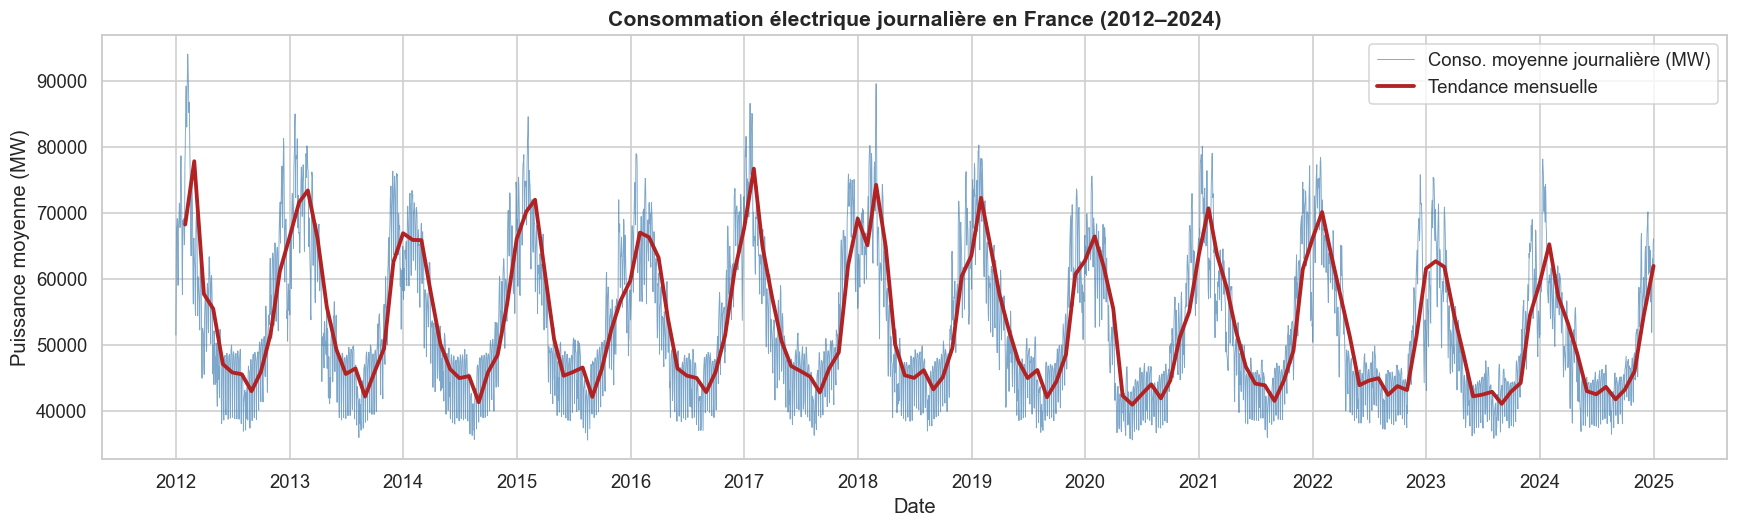

In [9]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_daily['Date'], df_daily['conso_mean_mw'], linewidth=0.6, alpha=0.7, color='steelblue', label='Conso. moyenne journalière (MW)')

# Tendance mensuelle
df_monthly = df_daily.set_index('Date')['conso_mean_mw'].resample('ME').mean()
ax.plot(df_monthly.index, df_monthly.values, linewidth=2.5, color='firebrick', label='Tendance mensuelle')

ax.set_title('Consommation électrique journalière en France (2012–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Puissance moyenne (MW)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

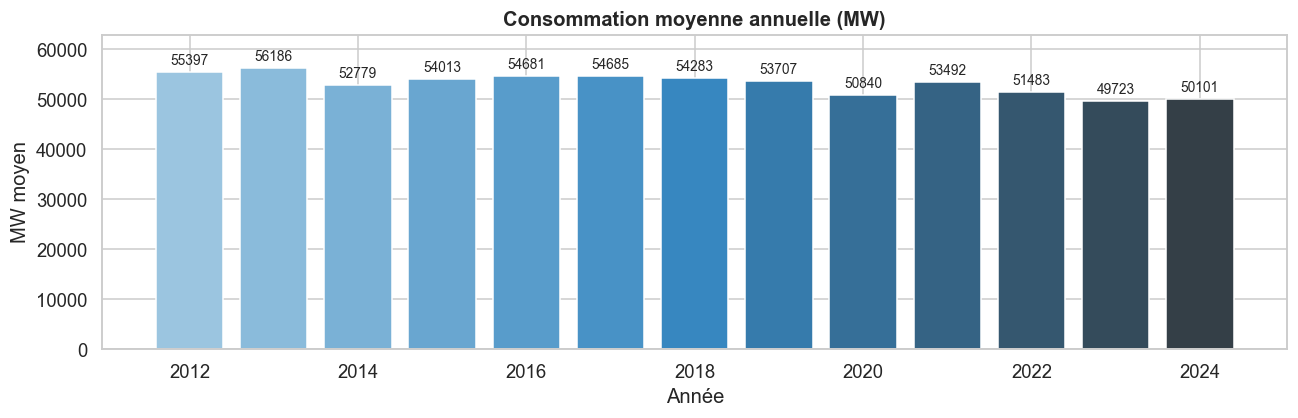

,year,conso_mean_mw,variation_%
0,2012,55396.961806,0.0
1,2013,56185.529852,1.4
2,2014,52779.499144,-4.7
3,2015,54012.877797,-2.5
4,2016,54681.287739,-1.3
5,2017,54685.462043,-1.3
6,2018,54283.219521,-2.0
7,2019,53707.436301,-3.0
8,2020,50840.467953,-8.2
9,2021,53492.347831,-3.4


In [10]:
# Consommation annuelle moyenne
df_yearly = df_daily.groupby('year')['conso_mean_mw'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(df_yearly['year'], df_yearly['conso_mean_mw'], color=sns.color_palette('Blues_d', len(df_yearly)))
ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
ax.set_title('Consommation moyenne annuelle (MW)', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('MW moyen')
ax.set_ylim(0, df_yearly['conso_mean_mw'].max() * 1.12)
plt.tight_layout()
plt.show()

# Variation par rapport à 2012
ref = df_yearly.loc[df_yearly['year']==2012, 'conso_mean_mw'].values[0]
df_yearly['variation_%'] = ((df_yearly['conso_mean_mw'] - ref) / ref * 100).round(1)
display(df_yearly)

## 5. Saisonnalité

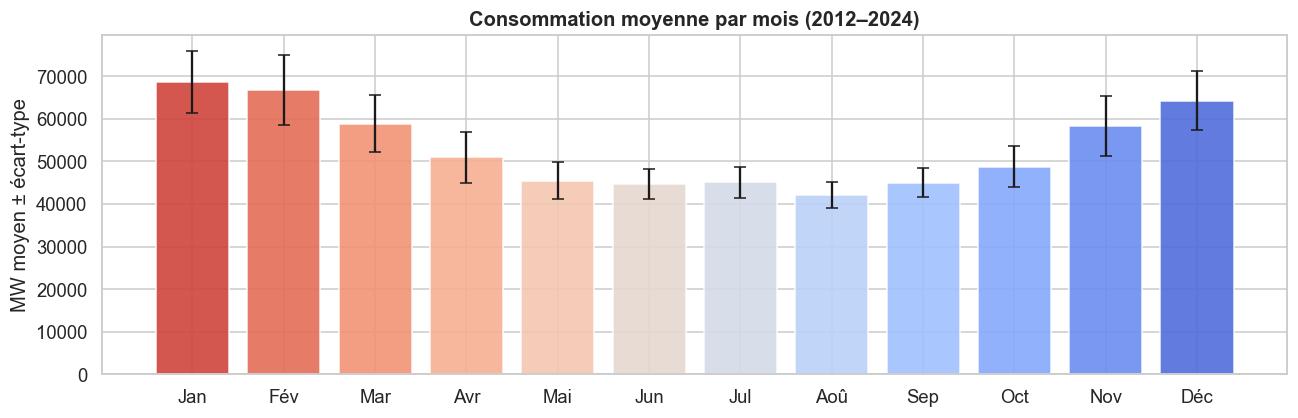

In [11]:
# Profil mensuel (toutes années confondues)
MONTH_NAMES = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

df_month = df_daily.groupby('month')['conso_mean_mw'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_month['month'], df_month['mean'], yerr=df_month['std'],
       color=sns.color_palette('coolwarm_r', 12), capsize=4, alpha=0.9)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_title('Consommation moyenne par mois (2012–2024)', fontweight='bold')
ax.set_ylabel('MW moyen ± écart-type')
plt.tight_layout()
plt.show()

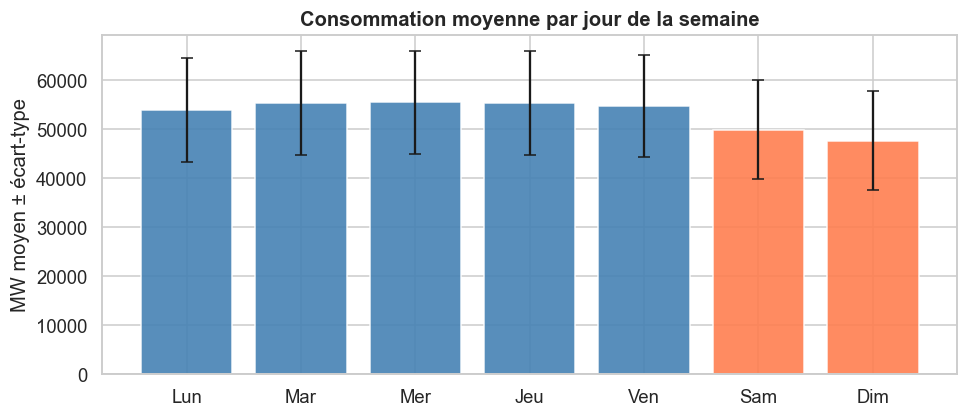

In [12]:
# Profil par jour de la semaine
DOW_NAMES = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

df_dow = df_daily.groupby('dayofweek')['conso_mean_mw'].agg(['mean', 'std']).reset_index()
colors = ['steelblue']*5 + ['coral']*2

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(df_dow['dayofweek'], df_dow['mean'], yerr=df_dow['std'],
       color=colors, capsize=4, alpha=0.9)
ax.set_xticks(range(7))
ax.set_xticklabels(DOW_NAMES)
ax.set_title('Consommation moyenne par jour de la semaine', fontweight='bold')
ax.set_ylabel('MW moyen ± écart-type')
plt.tight_layout()
plt.show()

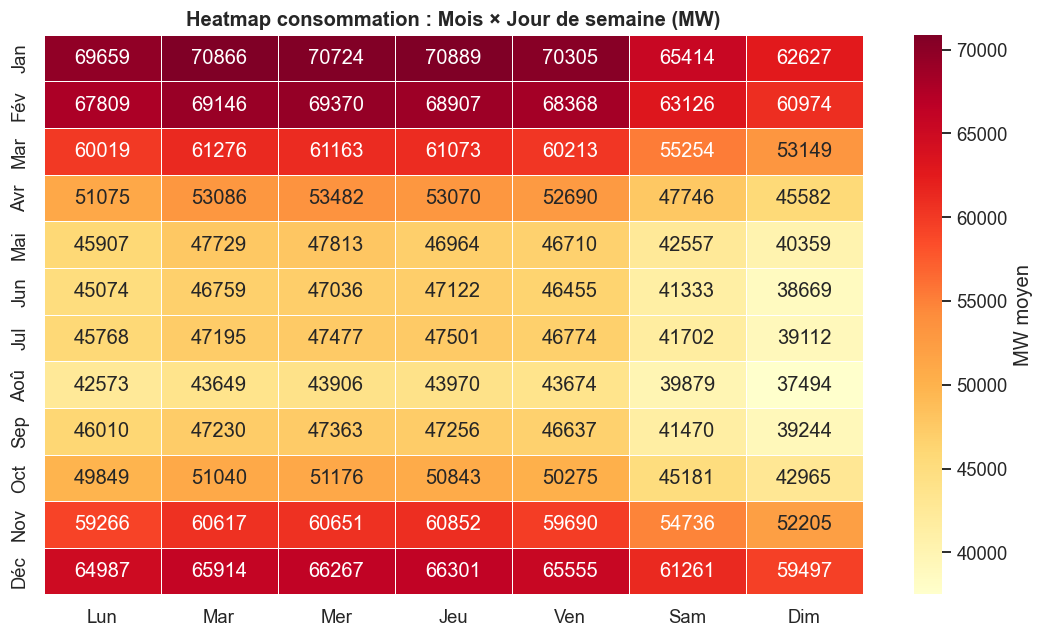

In [13]:
# Heatmap mois × jour de semaine
pivot = df_daily.groupby(['month', 'dayofweek'])['conso_mean_mw'].mean().unstack()
pivot.columns = DOW_NAMES
pivot.index = MONTH_NAMES

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'MW moyen'})
ax.set_title('Heatmap consommation : Mois × Jour de semaine (MW)', fontweight='bold')
plt.tight_layout()
plt.show()

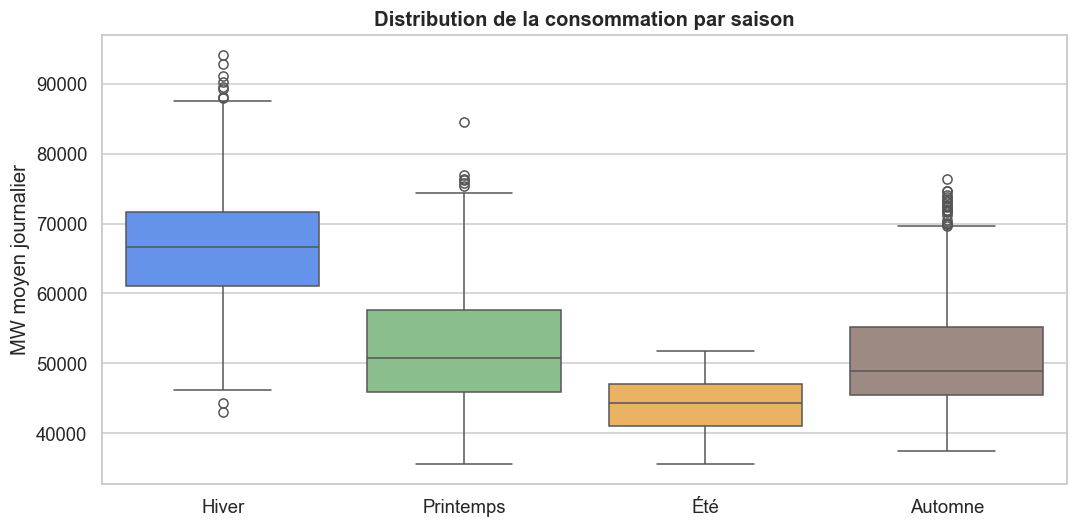

In [14]:
# Boxplot par saison
season_order = ['Hiver', 'Printemps', 'Été', 'Automne']
season_colors = ['#4e8cff', '#81c784', '#ffb74d', '#a1887f']

fig, ax = plt.subplots(figsize=(10, 5))
df_daily['season'] = pd.Categorical(df_daily['season'], categories=season_order, ordered=True)
sns.boxplot(data=df_daily, x='season', y='conso_mean_mw',
            palette=dict(zip(season_order, season_colors)), ax=ax)
ax.set_title('Distribution de la consommation par saison', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('MW moyen journalier')
plt.tight_layout()
plt.show()

## 6. Profil infra-journalier (demi-heures)

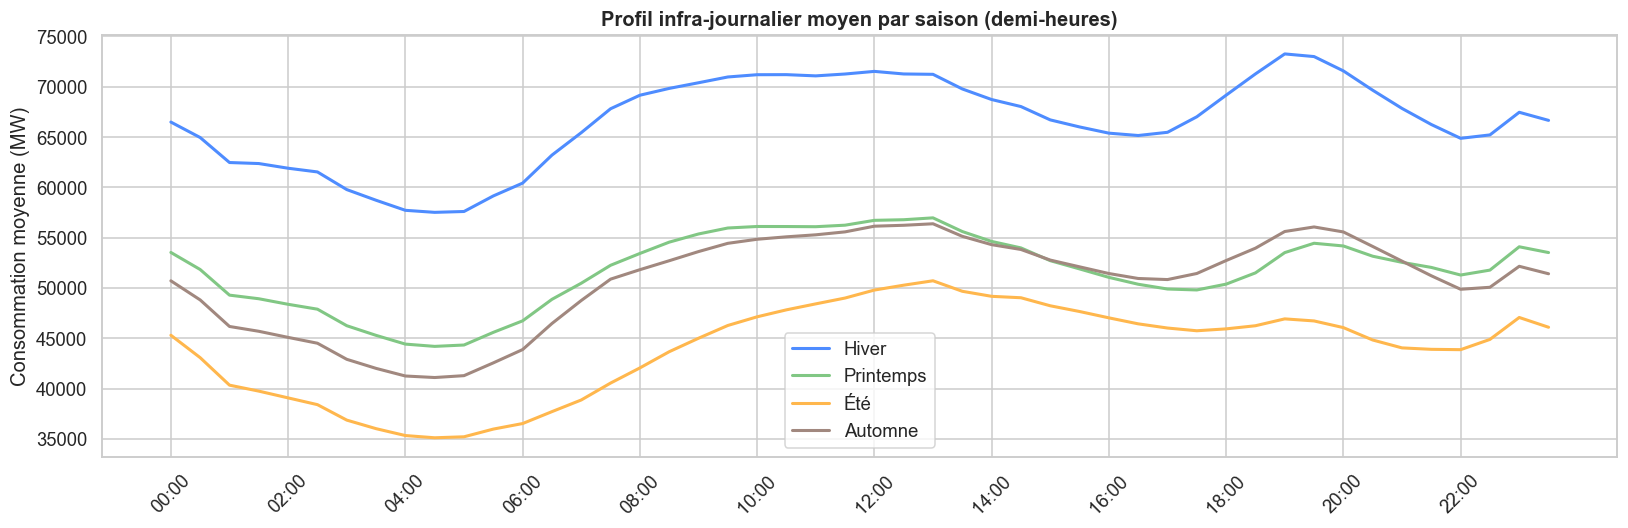

In [15]:
# Profil moyen sur 24h (demi-heures) par saison
df_intra = df_raw.copy()
df_intra['Date'] = pd.to_datetime(df_intra['Date'], errors='coerce')
df_intra['month'] = df_intra['Date'].dt.month
df_intra['season'] = df_intra['month'].map({
    12:'Hiver',1:'Hiver',2:'Hiver',
    3:'Printemps',4:'Printemps',5:'Printemps',
    6:'Été',7:'Été',8:'Été',
    9:'Automne',10:'Automne',11:'Automne'
})
df_intra['time_slot'] = df_intra['Heures'].str.strip()

# Ordre chronologique des demi-heures
time_slots = [f'{h:02d}:{m:02d}' for h in range(24) for m in [0, 30]]
df_intra_grp = df_intra[df_intra['time_slot'].isin(time_slots)].groupby(
    ['season', 'time_slot'])['Consommation'].mean().reset_index()
df_intra_grp['time_slot'] = pd.Categorical(df_intra_grp['time_slot'], categories=time_slots, ordered=True)
df_intra_grp = df_intra_grp.sort_values(['season','time_slot'])

fig, ax = plt.subplots(figsize=(15, 5))
for season, color in zip(season_order, season_colors):
    sub = df_intra_grp[df_intra_grp['season'] == season]
    if not sub.empty:
        ax.plot(range(len(sub)), sub['Consommation'], label=season, color=color, linewidth=2)

step = 4  # every 2h
ax.set_xticks(range(0, len(time_slots), step))
ax.set_xticklabels(time_slots[::step], rotation=45)
ax.set_title('Profil infra-journalier moyen par saison (demi-heures)', fontweight='bold')
ax.set_ylabel('Consommation moyenne (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Mix énergétique

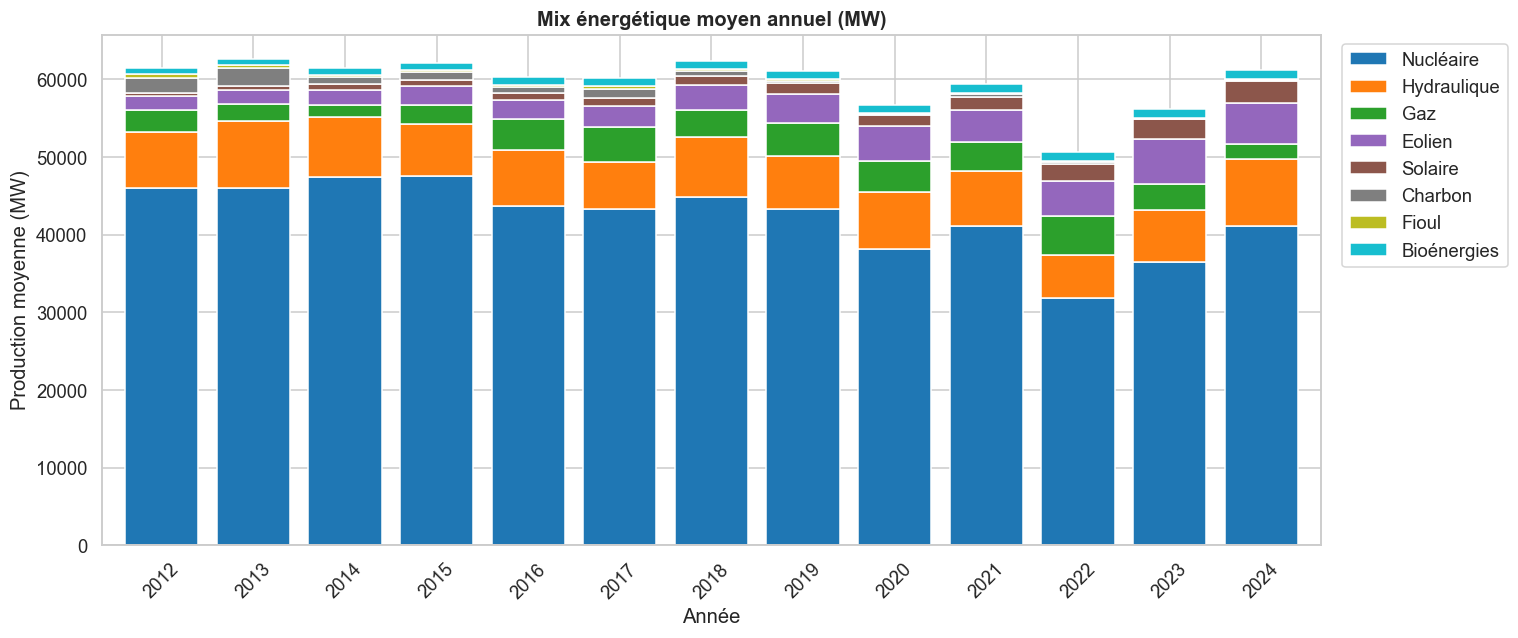

In [16]:
# Évolution du mix énergétique annuel
mix_cols = ['Nucléaire', 'Hydraulique', 'Gaz', 'Eolien', 'Solaire', 'Charbon', 'Fioul', 'Bioénergies']
mix_cols = [c for c in mix_cols if c in df_daily.columns]

df_mix_year = df_daily.groupby('year')[mix_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
df_mix_year.plot(kind='bar', stacked=True, ax=ax,
                 colormap='tab10', width=0.8)
ax.set_title('Mix énergétique moyen annuel (MW)', fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Production moyenne (MW)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

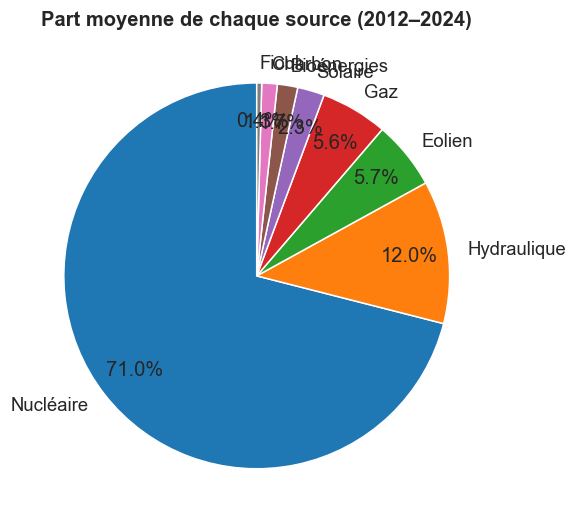

In [17]:
# Part de chaque source (moyenne globale 2012–2024)
mix_means = df_daily[mix_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_mix = sns.color_palette('tab10', len(mix_means))
wedges, texts, autotexts = ax.pie(
    mix_means.values,
    labels=mix_means.index,
    autopct='%1.1f%%',
    colors=colors_mix,
    startangle=90,
    pctdistance=0.8
)
ax.set_title('Part moyenne de chaque source (2012–2024)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Distribution de la consommation & détection d'outliers

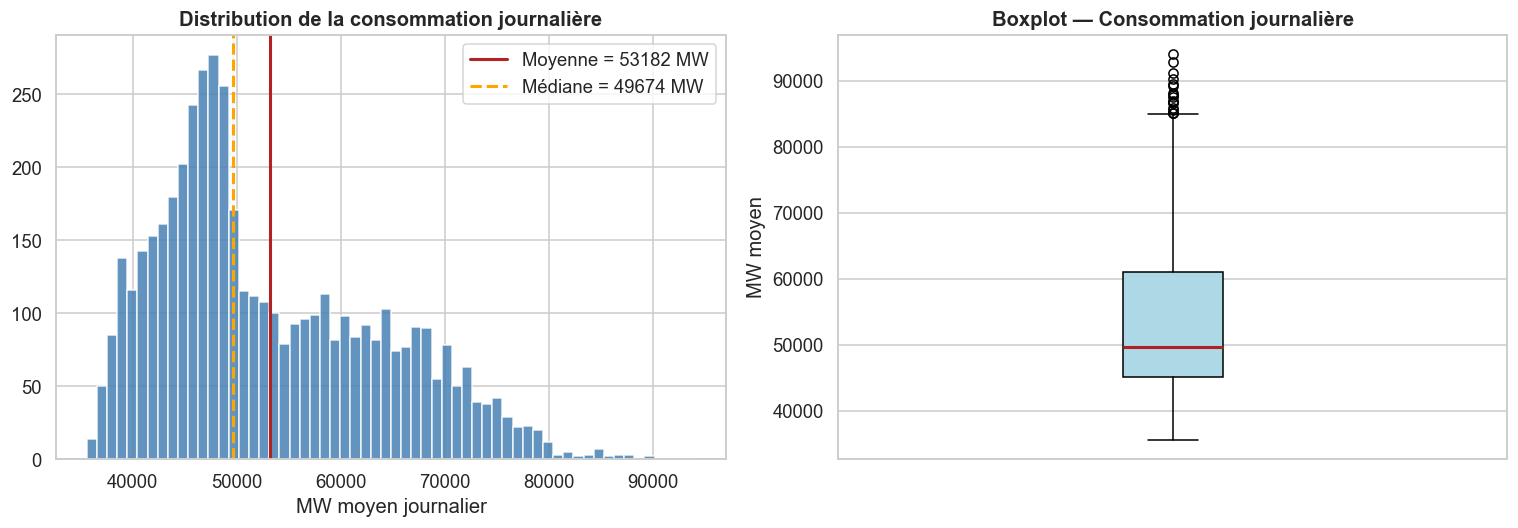

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df_daily['conso_mean_mw'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_daily['conso_mean_mw'].mean(), color='firebrick', lw=2, label=f"Moyenne = {df_daily['conso_mean_mw'].mean():.0f} MW")
axes[0].axvline(df_daily['conso_mean_mw'].median(), color='orange', lw=2, linestyle='--', label=f"Médiane = {df_daily['conso_mean_mw'].median():.0f} MW")
axes[0].set_title('Distribution de la consommation journalière', fontweight='bold')
axes[0].set_xlabel('MW moyen journalier')
axes[0].legend()

# Boxplot global
axes[1].boxplot(df_daily['conso_mean_mw'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='firebrick', linewidth=2))
axes[1].set_title('Boxplot — Consommation journalière', fontweight='bold')
axes[1].set_ylabel('MW moyen')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

In [19]:
# Détection d'outliers (IQR)
Q1 = df_daily['conso_mean_mw'].quantile(0.25)
Q3 = df_daily['conso_mean_mw'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_daily[(df_daily['conso_mean_mw'] < lower) | (df_daily['conso_mean_mw'] > upper)]
print(f'Seuils IQR : [{lower:.0f} MW, {upper:.0f} MW]')
print(f'Outliers détectés : {len(outliers)} jours ({len(outliers)/len(df_daily)*100:.1f}%)')
if not outliers.empty:
    display(outliers[['Date', 'conso_mean_mw', 'season', 'year']].sort_values('conso_mean_mw'))

Seuils IQR : [21114 MW, 85045 MW]
Outliers détectés : 17 jours (0.4%)


,Date,conso_mean_mw,season,year
1851,2017-01-25,85097.937500,Hiver,2017
34,2012-02-04,85132.437500,Hiver,2012
42,2012-02-12,85201.916667,Hiver,2012
1846,2017-01-20,85613.458333,Hiver,2017
1844,2017-01-18,85886.520833,Hiver,2017
1845,2017-01-19,86614.687500,Hiver,2017
43,2012-02-13,86770.687500,Hiver,2012
2249,2018-02-27,87012.250000,Hiver,2018
32,2012-02-02,87524.020833,Hiver,2012
41,2012-02-11,87951.187500,Hiver,2012


## 9. Corrélations

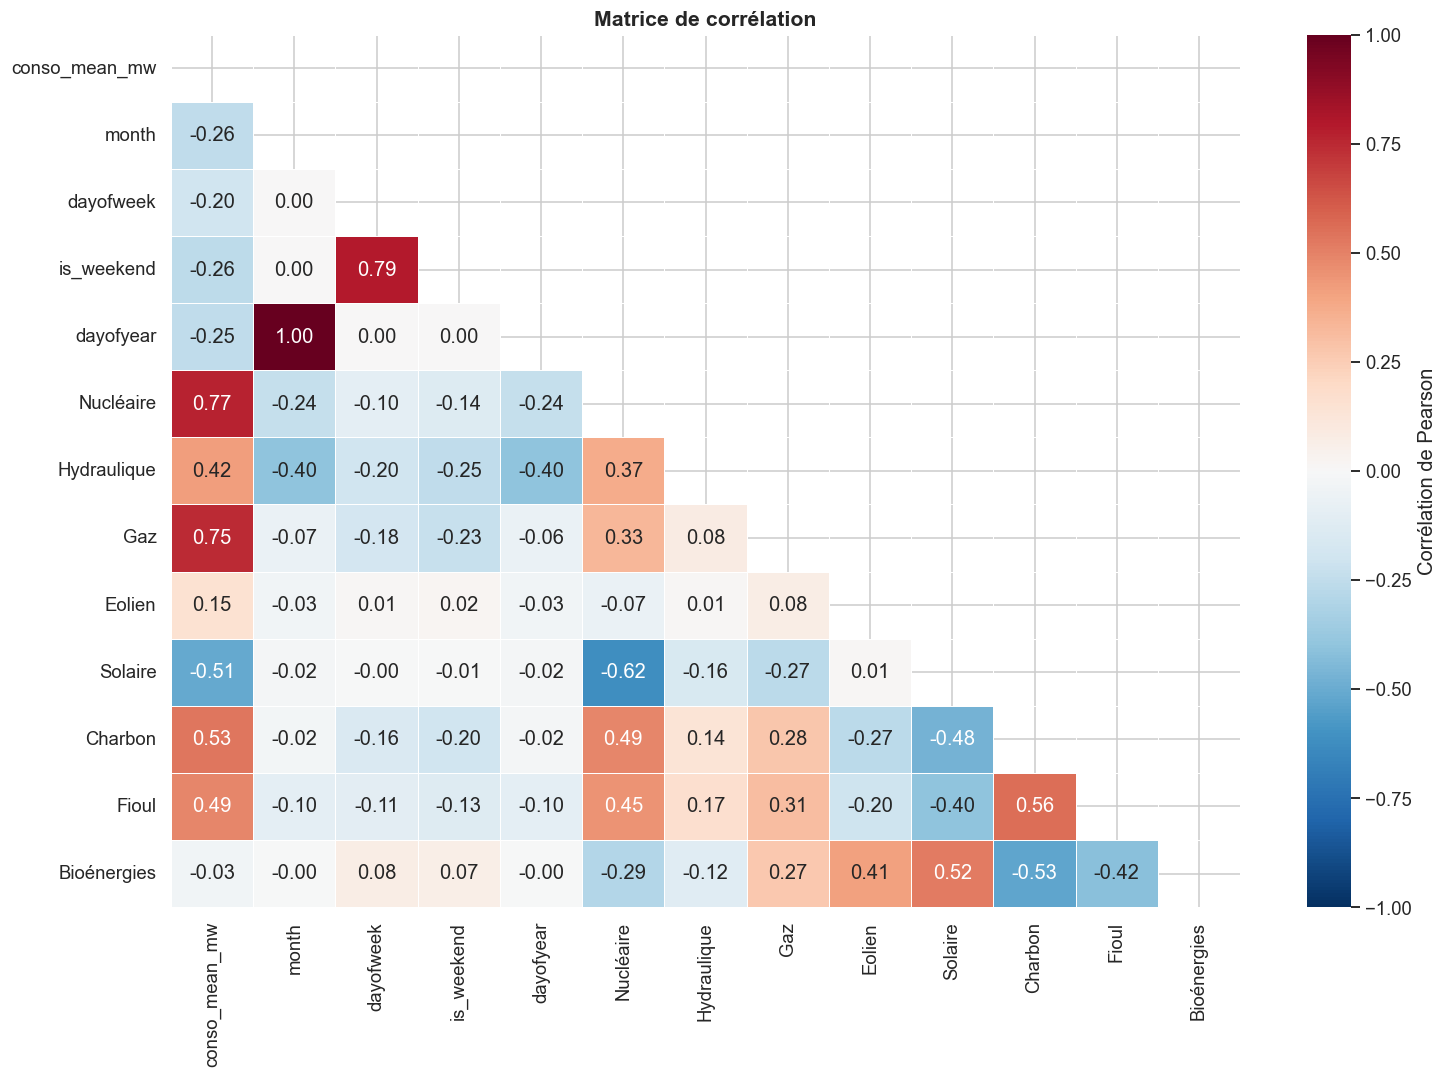

In [20]:
corr_cols = ['conso_mean_mw', 'month', 'dayofweek', 'is_weekend', 'dayofyear'] + mix_cols
corr_cols = [c for c in corr_cols if c in df_daily.columns]

corr_matrix = df_daily[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Corrélation de Pearson'})
ax.set_title('Matrice de corrélation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Top corrélations avec la cible
corr_target = corr_matrix['conso_mean_mw'].drop('conso_mean_mw').sort_values(key=abs, ascending=False)
print('Corrélations avec conso_mean_mw :')
display(corr_target.to_frame('corrélation').round(3))

Corrélations avec conso_mean_mw :


,corrélation
Nucléaire,0.766
Gaz,0.746
Charbon,0.532
Solaire,-0.513
Fioul,0.487
Hydraulique,0.417
is_weekend,-0.259
month,-0.257
dayofyear,-0.255
dayofweek,-0.202


## 10. Analyse de la prévision J-1 vs consommation réelle

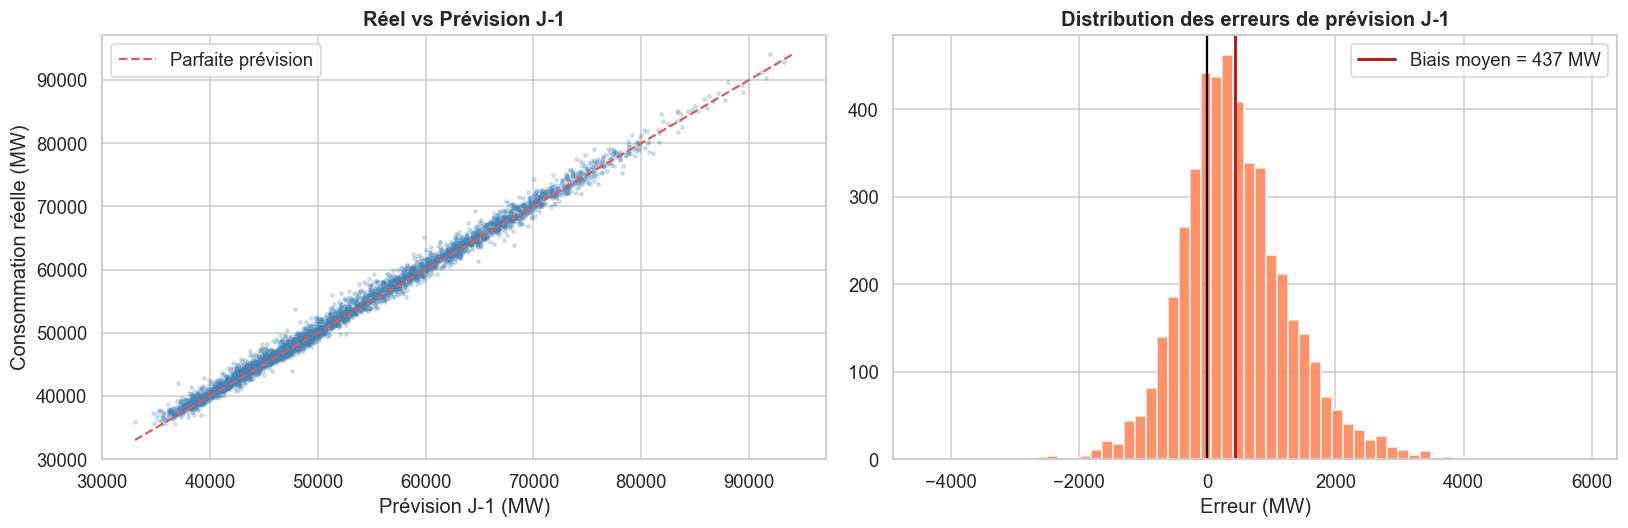

Benchmark prévision J-1 RTE :
  RMSE  = 967.5 MW
  MAPE  = 1.37 %
  R²    = 0.9920


In [22]:
df_prev = df_daily[['Date', 'conso_mean_mw', 'prevision_j1_mean']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter réel vs prévision
axes[0].scatter(df_prev['prevision_j1_mean'], df_prev['conso_mean_mw'],
                alpha=0.2, s=5, color='steelblue')
lims = [df_prev[['conso_mean_mw','prevision_j1_mean']].min().min(),
        df_prev[['conso_mean_mw','prevision_j1_mean']].max().max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Parfaite prévision')
axes[0].set_xlabel('Prévision J-1 (MW)')
axes[0].set_ylabel('Consommation réelle (MW)')
axes[0].set_title('Réel vs Prévision J-1', fontweight='bold')
axes[0].legend()

# Distribution des erreurs
errors = df_prev['conso_mean_mw'] - df_prev['prevision_j1_mean']
axes[1].hist(errors, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', lw=1.5)
axes[1].axvline(errors.mean(), color='firebrick', lw=2,
                label=f'Biais moyen = {errors.mean():.0f} MW')
axes[1].set_title('Distribution des erreurs de prévision J-1', fontweight='bold')
axes[1].set_xlabel('Erreur (MW)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Métriques de la prévision RTE
from sklearn.metrics import mean_squared_error, r2_score
rmse_rte = mean_squared_error(df_prev['conso_mean_mw'], df_prev['prevision_j1_mean']) ** 0.5
mape_rte = (errors.abs() / df_prev['conso_mean_mw']).mean() * 100
r2_rte   = r2_score(df_prev['conso_mean_mw'], df_prev['prevision_j1_mean'])
print(f'Benchmark prévision J-1 RTE :')
print(f'  RMSE  = {rmse_rte:.1f} MW')
print(f'  MAPE  = {mape_rte:.2f} %')
print(f'  R²    = {r2_rte:.4f}')

## 11. Autocorrélation temporelle

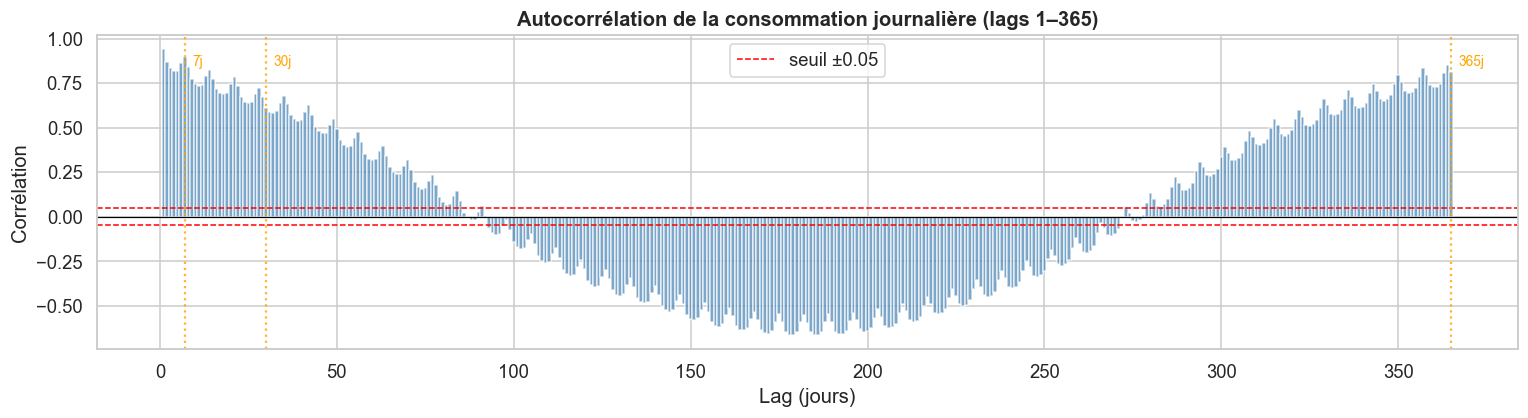

In [23]:
from pandas.plotting import autocorrelation_plot

conso_series = df_daily.set_index('Date')['conso_mean_mw']

# ACF manuelle sur 365 lags
lags = range(1, 366)
acf_vals = [conso_series.autocorr(lag=l) for l in lags]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(list(lags), acf_vals, width=1, color='steelblue', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.05, color='red', lw=1, linestyle='--', label='seuil ±0.05')
ax.axhline(-0.05, color='red', lw=1, linestyle='--')
# Marquer lags notables
for lag, label in [(7, '7j'), (30, '30j'), (365, '365j')]:
    if lag in lags:
        ax.axvline(lag, color='orange', lw=1.5, linestyle=':', alpha=0.8)
        ax.text(lag+2, max(acf_vals)*0.9, label, color='orange', fontsize=9)
ax.set_title('Autocorrélation de la consommation journalière (lags 1–365)', fontweight='bold')
ax.set_xlabel('Lag (jours)')
ax.set_ylabel('Corrélation')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Impact du COVID-19 (2020)

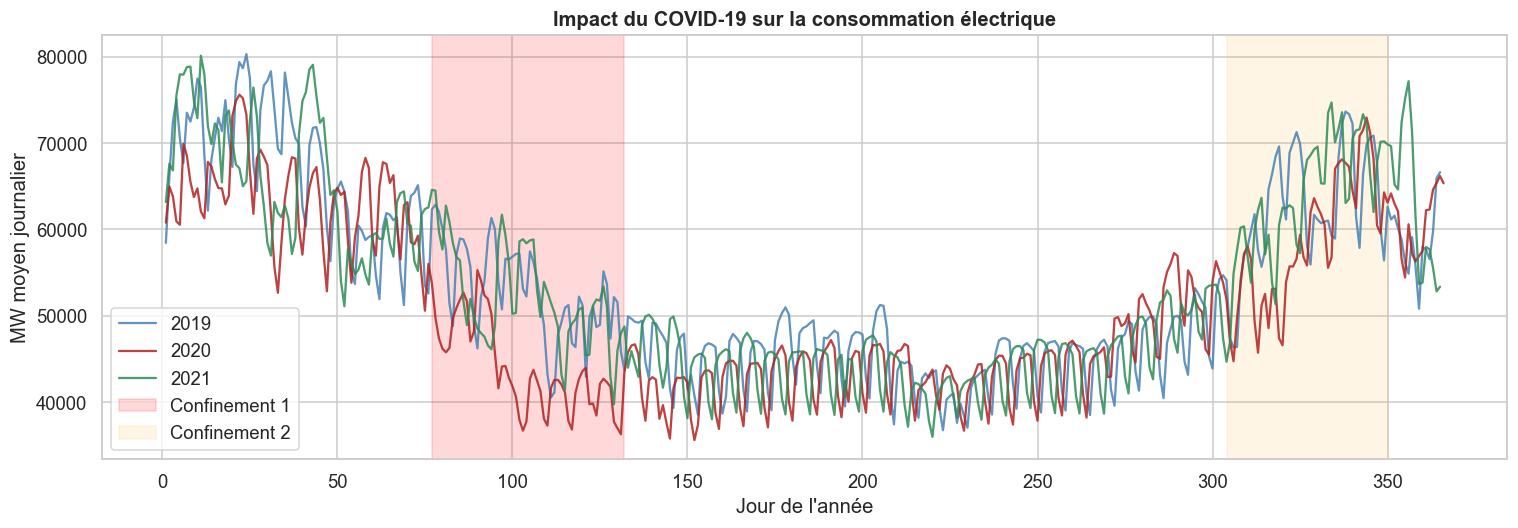

In [24]:
# Comparer 2019, 2020, 2021
years_covid = [2019, 2020, 2021]
colors_covid = ['steelblue', 'firebrick', 'seagreen']

fig, ax = plt.subplots(figsize=(14, 5))
for year, color in zip(years_covid, colors_covid):
    sub = df_daily[df_daily['year'] == year].copy()
    sub['doy'] = sub['Date'].dt.dayofyear
    ax.plot(sub['doy'], sub['conso_mean_mw'], label=str(year), color=color,
            linewidth=1.5, alpha=0.85)

# Confinement 1 (17 mars – 11 mai 2020)
ax.axvspan(77, 132, alpha=0.15, color='red', label='Confinement 1')
# Confinement 2 (30 oct – 15 déc 2020)
ax.axvspan(304, 350, alpha=0.1, color='orange', label='Confinement 2')

ax.set_title('Impact du COVID-19 sur la consommation électrique', fontweight='bold')
ax.set_xlabel('Jour de l\'année')
ax.set_ylabel('MW moyen journalier')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Synthèse — Features pour le ML

In [25]:
print("""
=== SYNTHÈSE EDA ===

CIBLE
  - conso_mean_mw : puissance moyenne journalière (MW)
  - Plage : ~29 000 – 88 000 MW   |   Moyenne : ~53 000 MW

PATTERNS IDENTIFIÉS
  1. Forte saisonnalité annuelle  → consommation ~30% plus élevée en hiver
  2. Cycle hebdomadaire           → -10 à -15% le week-end vs semaine
  3. Autocorrélation forte        → lag 1j, 7j, 365j très significatifs
  4. Tendance baissière 2012→2020 → sobriété + COVID (-15% en avril 2020)
  5. Rebond partiel 2021–2024

FEATURES RECOMMANDÉES POUR LE ML
  Temporelles:
    - month, dayofweek, dayofyear, quarter, is_weekend
    - sin/cos encoding (month, dayofyear) → cyclicité
  Lag features:
    - conso J-1, J-7, J-14, J-30, J-365
    - rolling mean 7j, 30j
  Météo (externe, non disponible dans ce dataset):
    - température moyenne → corrélation très forte avec la consommation

BENCHMARK PRÉVISION RTE (J-1)
  → RMSE, MAPE, R² affichés ci-dessus — base de comparaison pour nos modèles

DONNÉES ATYPIQUES
  - Jours fériés (non marqués dans le dataset)
  - Canicules estivales (pic de climatisation)
  - COVID-19 (2020)
""")


=== SYNTHÈSE EDA ===

CIBLE
  - conso_mean_mw : puissance moyenne journalière (MW)
  - Plage : ~29 000 – 88 000 MW   |   Moyenne : ~53 000 MW

PATTERNS IDENTIFIÉS
  1. Forte saisonnalité annuelle  → consommation ~30% plus élevée en hiver
  2. Cycle hebdomadaire           → -10 à -15% le week-end vs semaine
  3. Autocorrélation forte        → lag 1j, 7j, 365j très significatifs
  4. Tendance baissière 2012→2020 → sobriété + COVID (-15% en avril 2020)
  5. Rebond partiel 2021–2024

FEATURES RECOMMANDÉES POUR LE ML
  Temporelles:
    - month, dayofweek, dayofyear, quarter, is_weekend
    - sin/cos encoding (month, dayofyear) → cyclicité
  Lag features:
    - conso J-1, J-7, J-14, J-30, J-365
    - rolling mean 7j, 30j
  Météo (externe, non disponible dans ce dataset):
    - température moyenne → corrélation très forte avec la consommation

BENCHMARK PRÉVISION RTE (J-1)
  → RMSE, MAPE, R² affichés ci-dessus — base de comparaison pour nos modèles

DONNÉES ATYPIQUES
  - Jours fériés (non ma

In [26]:
# Sauvegarder le dataset journalier nettoyé
df_daily.to_csv('data/daily_consumption.csv', index=False)
print(f'Dataset journalier sauvegardé : data/daily_consumption.csv ({df_daily.shape[0]} lignes)')

Dataset journalier sauvegardé : data/daily_consumption.csv (4749 lignes)
